# Short Term Household Energy Usage Forecasting

**Objective:** Forecast short term household energy usage using historical time based patterns.

This notebook uses simple steps:

1. Parse the date and time columns
2. Resample minute level readings into hourly energy usage
3. Create time based features such as hour, weekday, weekend, and lag values
4. Train and compare ARIMA, Prophet, and XGBoost models
5. Evaluate models using MAE and RMSE
6. Plot actual vs forecasted energy usage

**Dataset used:** `household_power_consumption.csv`

## 1. Import Libraries

We will use common Python libraries for data handling, plotting, forecasting, and evaluation.

Prophet and XGBoost may not be installed in every environment. The notebook includes safe checks so the rest of the notebook can still run.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ARIMA / SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Optional libraries
try:
    from prophet import Prophet
    prophet_available = True
except Exception:
    prophet_available = False
    print('Prophet is not installed. Install it with: pip install prophet')

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except Exception:
    xgboost_available = False
    print('XGBoost is not installed. Install it with: pip install xgboost')

plt.rcParams['figure.figsize'] = (12, 5)

Prophet is not installed. Install it with: pip install prophet
XGBoost is not installed. Install it with: pip install xgboost


## 2. Load and Parse the Dataset

The dataset has separate `Date` and `Time` columns. We combine them into one datetime column, convert energy columns to numeric values, and set datetime as the index.

The symbol `?` is treated as a missing value.

In [6]:
file_path = r"D:\Data Analyst\internship\Task 2\New folder\household_power_consumption.csv"

# Read the CSV file
# na_values='?' converts missing symbols into NaN
df = pd.read_csv(file_path, na_values=['?'])

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (1048575, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# Combine Date and Time into one datetime column
# dayfirst=True is used because dates are in DD/MM/YYYY format
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Convert important numeric columns
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where datetime or target column is missing
df = df.dropna(subset=['datetime', 'Global_active_power'])

# Set datetime as index
df = df.set_index('datetime').sort_index()

print('Date range:', df.index.min(), 'to', df.index.max())
df.head()

Date range: 2006-12-16 17:24:00 to 2008-12-13 21:38:00


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Insight

The original data is recorded at a very detailed minute level. For short term forecasting, hourly usage is easier to model and visualize. It also reduces noise and makes the models faster.

## 3. Exploratory Data Analysis

In this step, we check missing values, summary statistics, and basic time based patterns.

In [8]:
# Basic information
print('Dataset shape after cleaning:', df.shape)
print('Missing values:')
print(df[numeric_cols].isna().sum())

print('Summary statistics:')
df[numeric_cols].describe()

Dataset shape after cleaning: (1044506, 9)
Missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
Summary statistics:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


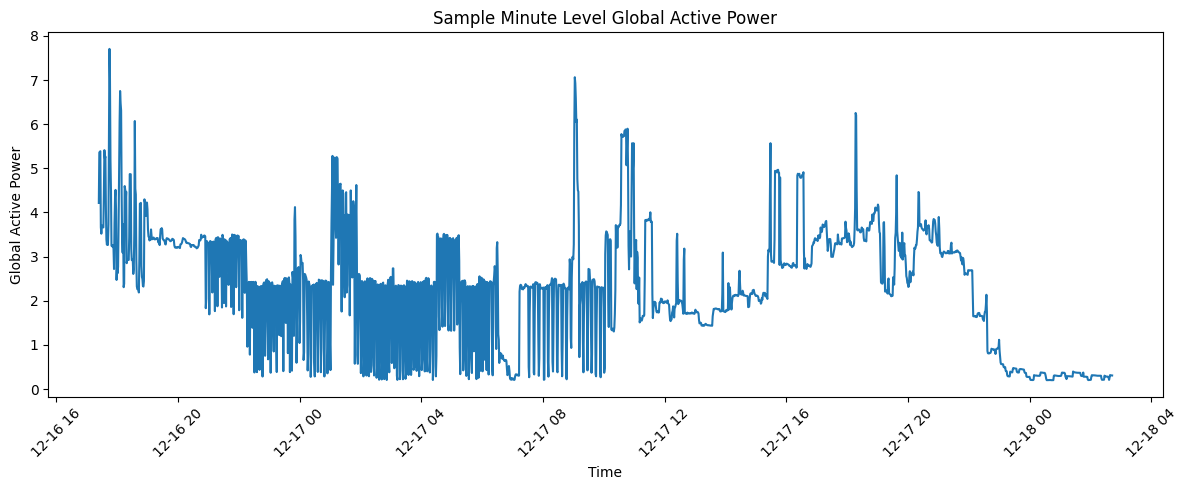

In [9]:
# Plot a small sample of minute level power usage
sample_data = df['Global_active_power'].iloc[:2000]

plt.figure()
plt.plot(sample_data.index, sample_data.values)
plt.title('Sample Minute Level Global Active Power')
plt.xlabel('Time')
plt.ylabel('Global Active Power')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Minute level energy usage can fluctuate sharply because household activity changes quickly. Resampling to hourly values helps reveal clearer patterns.

## 4. Resample the Time Series Data

We resample the data to hourly average energy usage.

Target variable:

`Global_active_power` = household active power consumption.

In [ ]:
"# Resample to hourly average power usage
hourly = df['Global_active_power'].resample('H').mean().to_frame(name='energy_usage')

# Fill small missing gaps using time based interpolation
hourly['energy_usage'] = hourly['energy_usage'].interpolate(method='time')

print('Hourly data shape:', hourly.shape)
hourly.head()

ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

In [ ]:
plt.figure()
plt.plot(hourly.index, hourly['energy_usage'])
plt.title('Hourly Household Energy Usage')
plt.xlabel('Date')
plt.ylabel('Energy Usage')
plt.tight_layout()
plt.show()

### Insight

The hourly series shows long term changes and repeated daily patterns. These patterns are useful for forecasting short term household energy usage.

## 5. Engineer Time Based Features

We create simple time based features:

- Hour of day
- Day of week
- Weekend flag
- Month
- Lag values from previous hours
- Rolling average of the previous 24 hours

These features help machine learning models such as XGBoost understand time patterns.

In [ ]:
def create_time_features(data):
    data = data.copy()
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)
    data['month'] = data.index.month
    
    # Lag features
    data['lag_1'] = data['energy_usage'].shift(1)
    data['lag_24'] = data['energy_usage'].shift(24)
    data['rolling_24_mean'] = data['energy_usage'].shift(1).rolling(window=24).mean()
    
    return data

feature_data = create_time_features(hourly)
feature_data = feature_data.dropna()

feature_data.head()

In [ ]:
# Average usage by hour of day
hourly_pattern = feature_data.groupby('hour')['energy_usage'].mean()

plt.figure()
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Usage')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [ ]:
# Average usage on weekday vs weekend
weekend_pattern = feature_data.groupby('is_weekend')['energy_usage'].mean()
weekend_pattern.index = ['Weekday', 'Weekend']

plt.figure()
plt.bar(weekend_pattern.index, weekend_pattern.values)
plt.title('Average Energy Usage: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Energy Usage')
plt.tight_layout()
plt.show()

### Insight

The hour of day often matters because people use more electricity during active home hours. Weekend usage may also differ from weekday usage because household routines change.

## 6. Train Test Split

For time series forecasting, we do not randomly split the data. We keep the latest 48 hours as test data and train on the earlier data.

This simulates a real forecasting situation where past data is used to predict future usage.

In [ ]:
# Use recent data only to keep models simple and fast
# You can increase this from 90 days to more days if your computer is fast enough
recent_data = feature_data.last('90D')

forecast_horizon = 48  # forecast next 48 hours
train = recent_data.iloc[:-forecast_horizon]
test = recent_data.iloc[-forecast_horizon:]

print('Training period:', train.index.min(), 'to', train.index.max())
print('Testing period:', test.index.min(), 'to', test.index.max())
print('Train shape:', train.shape)
print('Test shape:', test.shape)

## 7. Helper Function for Evaluation

We compare models using:

- **MAE:** Mean Absolute Error. Lower is better.
- **RMSE:** Root Mean Squared Error. Lower is better and penalizes large errors more strongly.

In [ ]:
def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse}

results = []
forecast_df = pd.DataFrame(index=test.index)
forecast_df['Actual'] = test['energy_usage']

## 8. Model 1: ARIMA

ARIMA is a traditional time series model. It uses past values and trends in the series to make forecasts.

To keep the code simple, we use a basic SARIMAX model with order `(1, 1, 1)`.

In [ ]:
# ARIMA / SARIMAX model
arima_model = SARIMAX(
    train['energy_usage'],
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_fit = arima_model.fit(disp=False)
arima_forecast = arima_fit.forecast(steps=forecast_horizon)

forecast_df['ARIMA'] = arima_forecast.values
results.append(evaluate_model('ARIMA', test['energy_usage'], forecast_df['ARIMA']))

forecast_df[['Actual', 'ARIMA']].head()

### ARIMA Insight

ARIMA is simple and useful for short term forecasting. However, it may not fully capture features such as hour of day or weekend patterns unless more advanced seasonal settings are added.

## 9. Model 2: Prophet

Prophet is designed for time series forecasting with trend and seasonality.

If Prophet is not installed, run this command in a notebook cell:

```python
pip install prophet
```

In [ ]:
if prophet_available:
    prophet_train = train.reset_index()[['datetime', 'energy_usage']]
    prophet_train.columns = ['ds', 'y']

    prophet_test = test.reset_index()[['datetime', 'energy_usage']]
    prophet_test.columns = ['ds', 'y']

    prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    prophet_model.fit(prophet_train)

    future = prophet_model.make_future_dataframe(periods=forecast_horizon, freq='H')
    prophet_prediction = prophet_model.predict(future)

    prophet_forecast = prophet_prediction.tail(forecast_horizon)['yhat'].values
    forecast_df['Prophet'] = prophet_forecast

    results.append(evaluate_model('Prophet', test['energy_usage'], forecast_df['Prophet']))
    display(forecast_df[['Actual', 'Prophet']].head())
else:
    print('Prophet was skipped because it is not installed.')

### Prophet Insight

Prophet can capture daily and weekly seasonality. This is useful for household power data because energy usage often follows repeated routines.

## 10. Model 3: XGBoost

XGBoost is a machine learning model. It does not understand time automatically, so we provide time features and lag features.

Features used:

- hour
- dayofweek
- is_weekend
- month
- lag_1
- lag_24
- rolling_24_mean

In [ ]:
feature_cols = ['hour', 'dayofweek', 'is_weekend', 'month', 'lag_1', 'lag_24', 'rolling_24_mean']

if xgboost_available:
    X_train = train[feature_cols]
    y_train = train['energy_usage']
    X_test = test[feature_cols]
    y_test = test['energy_usage']

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)
    xgb_forecast = xgb_model.predict(X_test)

    forecast_df['XGBoost'] = xgb_forecast
    results.append(evaluate_model('XGBoost', y_test, forecast_df['XGBoost']))

    forecast_df[['Actual', 'XGBoost']].head()
else:
    print('XGBoost was skipped because it is not installed.')

### XGBoost Insight

XGBoost can perform well when strong lag and time based features are available. It often captures patterns such as daily cycles better than a very basic ARIMA model.

## 11. Compare Model Performance

Lower MAE and RMSE values mean better forecasting performance.

In [ ]:
results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

In [ ]:
plt.figure()
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title('Model Comparison by RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

### Model Comparison Insight

The model with the lowest RMSE gives the best overall forecast in this experiment. However, model performance may change if you increase the training period, forecast more hours, or tune the model parameters.

## 12. Plot Actual vs Forecasted Energy Usage

This plot helps us visually compare model predictions with real usage values.

In [ ]:
plt.figure()
plt.plot(forecast_df.index, forecast_df['Actual'], label='Actual', linewidth=2)

for col in forecast_df.columns:
    if col != 'Actual':
        plt.plot(forecast_df.index, forecast_df[col], label=col)

plt.title('Actual vs Forecasted Household Energy Usage')
plt.xlabel('Datetime')
plt.ylabel('Energy Usage')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Final Insights

**Key findings:**

1. Household energy usage has clear time based patterns.
2. Hour of day is an important feature because daily routines affect power usage.
3. Weekend behavior can differ from weekday behavior.
4. ARIMA is easy to use for time series but may miss detailed daily behavior.
5. Prophet is useful when daily and weekly seasonality are important.
6. XGBoost can perform well when lag features and time features are added.

**Business use:**

Energy providers can use short term forecasts to plan demand, detect unusual usage, and recommend better energy saving schedules to customers.

## 14. What You Learned

By completing this notebook, you practiced:

- Time series parsing and resampling
- Time based feature engineering
- ARIMA, Prophet, and XGBoost forecasting
- Model evaluation using MAE and RMSE
- Actual vs forecast visualization